## Problem 2: Calculating NDVI (12 points)

In this problem, we will work with the same satellite imagery data as we used during the lesson. Specifically, we will explore the Sentinel-2 satellite image from Nuuksio National Park in Finland. The data is obtained from the [Copernicus Data Space Ecosystem](https://dataspace.copernicus.eu). Our objective is to explore, process the data, and ultimately calculate the NDVI (Normalized Difference Vegetation Index).

### What is NDVI?

NDVI (Normalized Difference Vegetation Index) is a simple, widely used index for assessing vegetation health and coverage based on satellite imagery. NDVI is calculated by comparing the Near Infrared (NIR) and Red bands of satellite data. Vegetation reflects more NIR light and absorbs more visible red light, so the NDVI value provides insight into the density and health of vegetation.

The formula to calculate NDVI is:

$$
NDVI = \frac{(NIR - Red)}{(NIR + Red)}
$$

- **NIR (Near Infrared)** corresponds to Band 8 for Sentinel-2 imagery.
- **Red** corresponds to Band 4 for Sentinel-2 imagery.

NDVI values range from -1 to +1, where higher values indicate healthier and denser vegetation.

### Sentinel-2 Band Reference

For Sentinel-2 imagery, the bands are predefined and consistent across products. Here is a quick reference for the Sentinel-2 bands:

| **Band**   | **Description**                     | **Wavelength (nm)** |
|------------|-------------------------------------|---------------------|
| Band 1     | Coastal aerosol                     | 443 nm              |
| Band 2     | Blue                                | 490 nm              |
| Band 3     | Green                               | 560 nm              |
| Band 4     | Red                                 | 665 nm              |
| Band 5     | Vegetation Red Edge                 | 705 nm              |
| Band 6     | Vegetation Red Edge                 | 740 nm              |
| Band 7     | Vegetation Red Edge                 | 783 nm              |
| Band 8     | Near Infrared                       | 842 nm              |
| Band 8A    | Narrow Near Infrared                | 865 nm              |
| Band 9     | Water Vapor                         | 945 nm              |
| Band 10    | Short-Wave Infrared – Cirrus        | 1375 nm             |
| Band 11    | Short-Wave Infrared                 | 1610 nm             |
| Band 12    | Short-Wave Infrared                 | 2190 nm             |

## (2a) - Read the raster and get the metadata (1 point)

As the first step read the raster file from data directory `data/sentinel2_Nuuksio_small.tif` as `sentinel_raster`. Provide the following information from the raster (use the same variable names and format):

```
data_crs = "the CRS of our raster data"
resolution = "as string in this format X*Y"
total_pixels = "total number of pixels across all bands as integer"
```

Remember to print the values. 

In [1]:
import pathlib
NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / "Exercise-6-data"

In [2]:
import rioxarray as rxr

raster_file = DATA_DIRECTORY / 'sentinel2_Nuuksio_small.tif'

sentinel_raster = rxr.open_rasterio(raster_file)

In [3]:
print(sentinel_raster)

<xarray.DataArray (band: 12, y: 723, x: 910)> Size: 32MB
[7895160 values with dtype=float32]
Coordinates:
  * band         (band) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * x            (x) float64 7kB 3.667e+05 3.667e+05 ... 3.757e+05 3.757e+05
  * y            (y) float64 6kB 6.696e+06 6.696e+06 ... 6.689e+06 6.689e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0


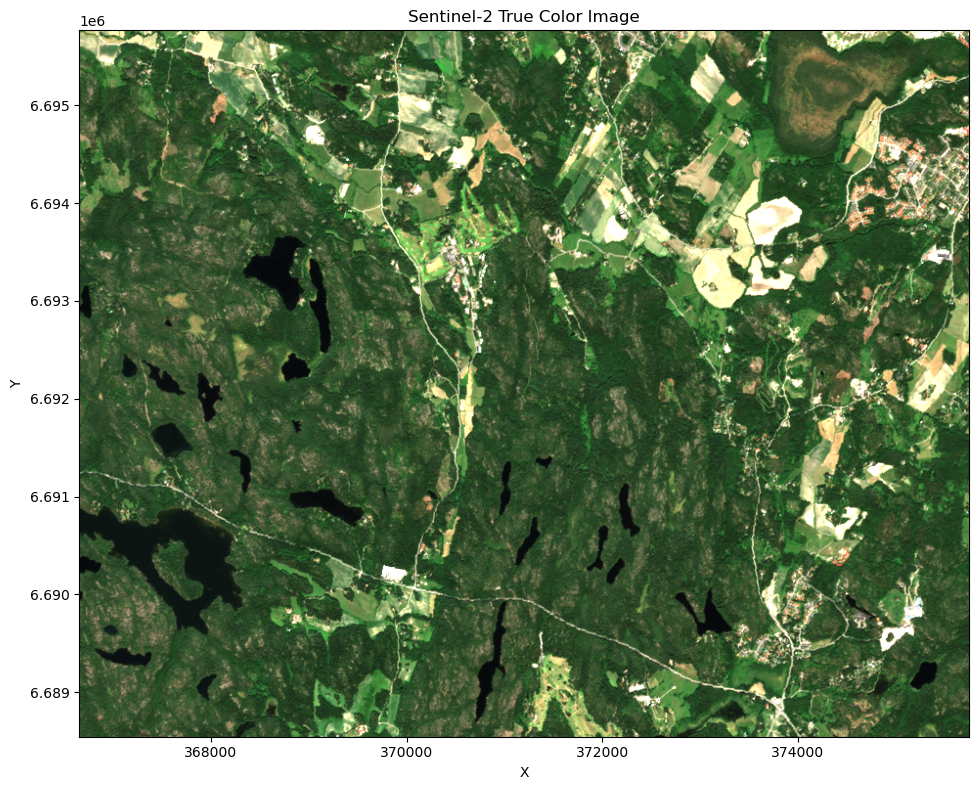

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Extract RGB bands for true color visualization
red = sentinel_raster.sel(band=4)
green = sentinel_raster.sel(band=3)
blue = sentinel_raster.sel(band=2)

# Stack the bands into an RGB array
rgb = np.stack([red.values, green.values, blue.values], axis=-1)

# Normalize using percentile 98
p98 = np.percentile(rgb, 98)
rgb_normalized = np.clip(rgb / p98, 0, 1)

# Apply gamma correction (gamma > 1 hace la imagen más oscura)
gamma = 1.3 # Ajusta entre 1.2-1.5 según prefieras
rgb_brightened = rgb_normalized ** (1/gamma)

# Plot the true color image
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(rgb_normalized, extent=[red.x.min(), red.x.max(), red.y.min(), red.y.max()])
ax.set_title('Sentinel-2 True Color Image')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.tight_layout()
plt.show()

## (2b) - Map NIR and RED bands (2 points)

Visualize the Near Infrared (NIR) and Red bands as individual raster plots (use subplots). You can decide what color you want to us efor your visulizations. 

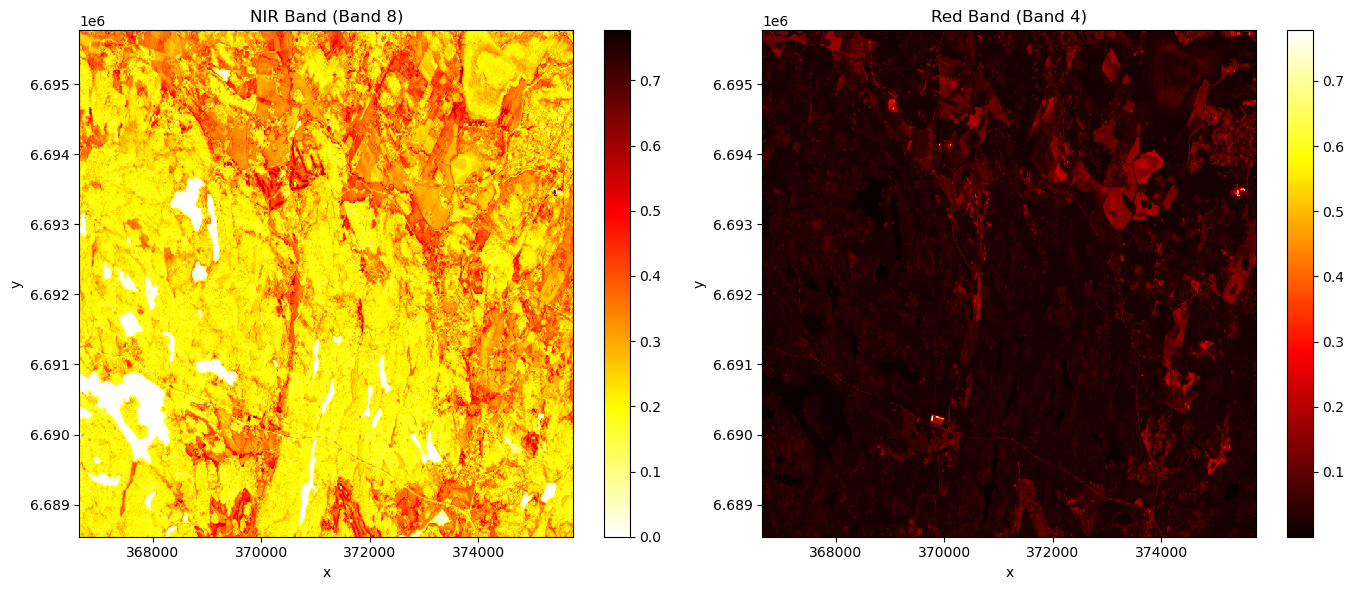

In [5]:

# Extract NIR (Band 8) and Red (Band 4) bands
nir_band = sentinel_raster.sel(band=8)
red_band = sentinel_raster.sel(band=4)

# Create subplots for NIR and Red bands
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Plot NIR band
nir_band.plot(ax=axes[0], cmap='hot_r')
axes[0].set_title('NIR Band (Band 8)')

# Plot Red band
red_band.plot(ax=axes[1], cmap='hot')
axes[1].set_title('Red Band (Band 4)')

plt.tight_layout()
plt.show()

## (2c) - Calculate the NDVI (5 points)

Calculate the NDVI using the formula provided above. Store the resulting raster as `NDVI` and export it as `NDVI.tif`. Finally, plot the NDVI raster. 


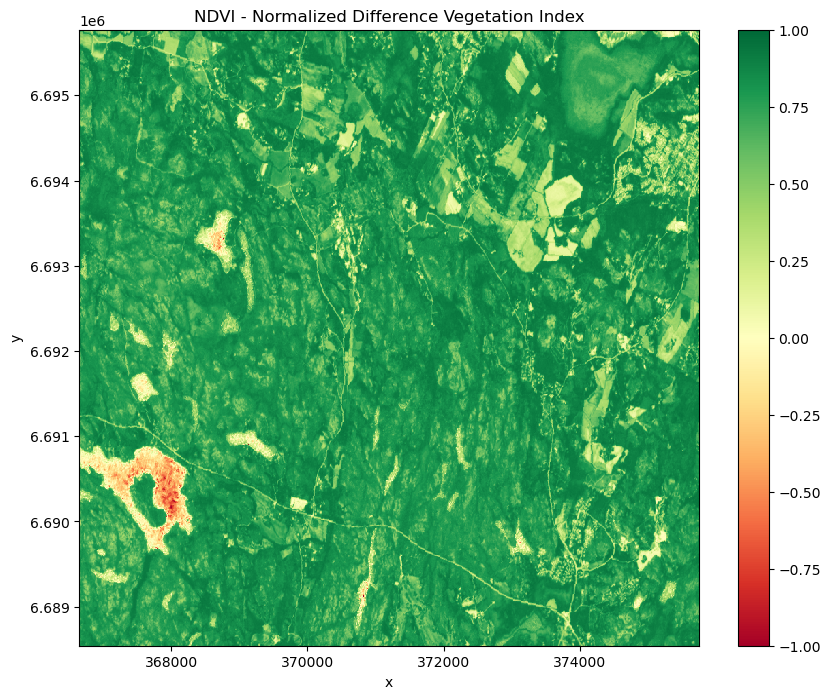

In [6]:
# Calculate NDVI
NDVI = (nir_band - red_band) / (nir_band + red_band)

# Export NDVI raster
NDVI.rio.to_raster(DATA_DIRECTORY / "NDVI.tif")

# Plot the NDVI raster
NDVI.plot(cmap='RdYlGn', figsize=(10, 8))
plt.title('NDVI - Normalized Difference Vegetation Index')
plt.show()

## (2d) - Reclassify the NDVI raster (4 points)

In this task, you will reclassify the NDVI values into distinct vegetation categories and visualize the result.

1. **Reclassify the NDVI values**: 
   - Create the following NDVI classification:
     - NDVI < 0.2: **Non-Vegetated**
     - 0.2 ≤ NDVI < 0.5: **Sparse Vegetation**
     - 0.5 ≤ NDVI: **Dense Vegetation**
   - Use appropriate values to represent each class (1 for Non-Vegetated, 2 for Sparse Vegetation, 3 for Dense Vegetation).

2. **Visualize the Reclassified NDVI**: 
   - Plot the reclassified NDVI using a discrete color map where each class has a distinct color.
   - Use a suitable color scheme to clearly differentiate between the classes (e.g., brown for Non-Vegetated, yellow for Sparse Vegetation, green for Dense Vegetation).




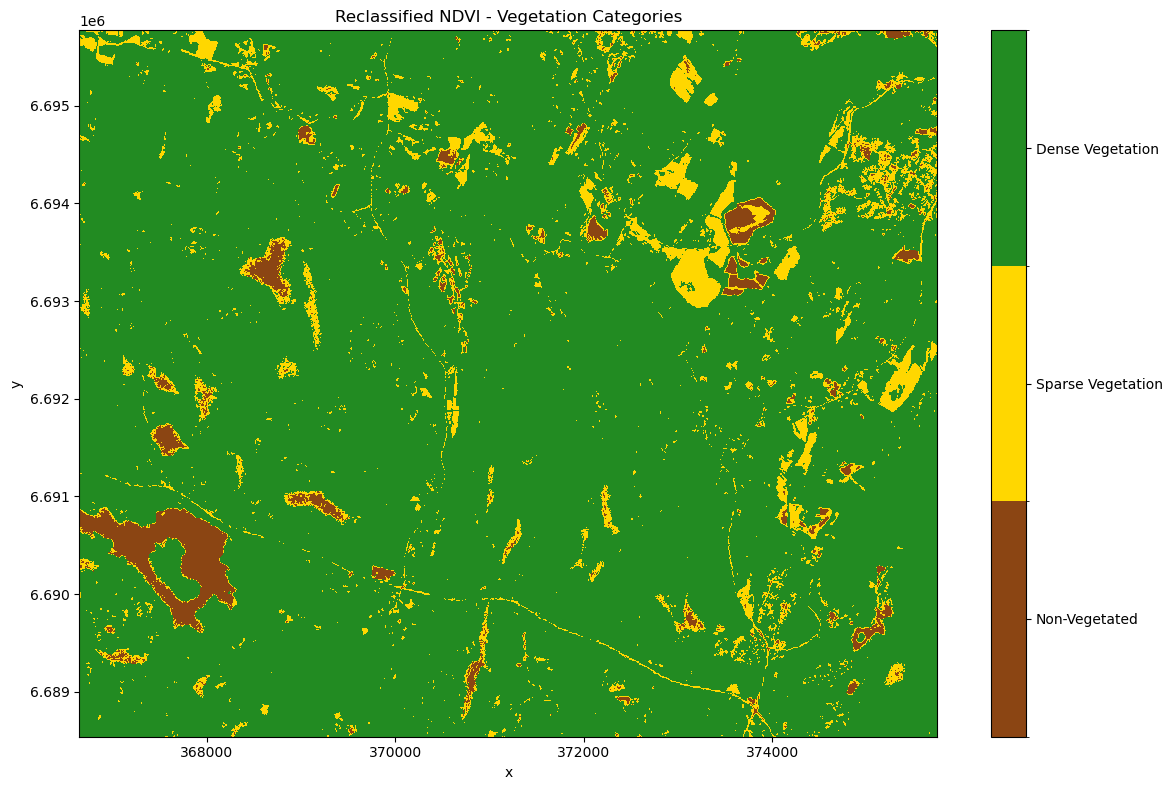

In [7]:
import numpy as np

# Create a copy of NDVI for reclassification
NDVI_classified = NDVI.copy()

# Reclassify NDVI values into vegetation categories
# 1 = Non-Vegetated (NDVI < 0.2)
# 2 = Sparse Vegetation (0.2 ≤ NDVI < 0.5)
# 3 = Dense Vegetation (NDVI ≥ 0.5)

NDVI_classified.values = np.where(NDVI.values < 0.2, 1,
                                   np.where((NDVI.values >= 0.2) & (NDVI.values < 0.5), 2, 3))

# Create a custom colormap: brown, yellow, green
colors = ['#8B4513', '#FFD700', '#228B22']  # Brown, Yellow, Green
n_bins = 3
cmap = plt.cm.colors.ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5]
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

# Plot the reclassified NDVI
fig, ax = plt.subplots(figsize=(12, 8))
NDVI_classified.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=True)

# Add labels
ax.set_title('Reclassified NDVI - Vegetation Categories')
cbar = ax.collections[0].colorbar
cbar.set_ticks([1, 2, 3])
cbar.set_ticklabels(['Non-Vegetated', 'Sparse Vegetation', 'Dense Vegetation'])

plt.tight_layout()
plt.show()

# Export the reclassified raster
NDVI_classified.rio.to_raster(DATA_DIRECTORY / "NDVI_classified.tif")

### **Answer these questions**:
   - Q1: How does the distribution of vegetation classes compare across the area?
   - Q2: Are there more areas with sparse or dense vegetation?

- A1: The area is dominated by dense vegetation, followed by sparse vegetation areas and the non-vegetated areas, that mainly corrspond with lakes.
- A2: There are more areas with dense vegetation

## (2e) Optional Raster value histogram - (0 point)

Use your previous skills with `matplotlib` to create a histogram of the raster values from the original NDVI raster (before reclassification). The histogram should visualize the distribution of NDVI values across the dataset, providing insights into the spread and frequency of different vegetation index values. Customize the bins and labels as needed to make the plot clear and informative.


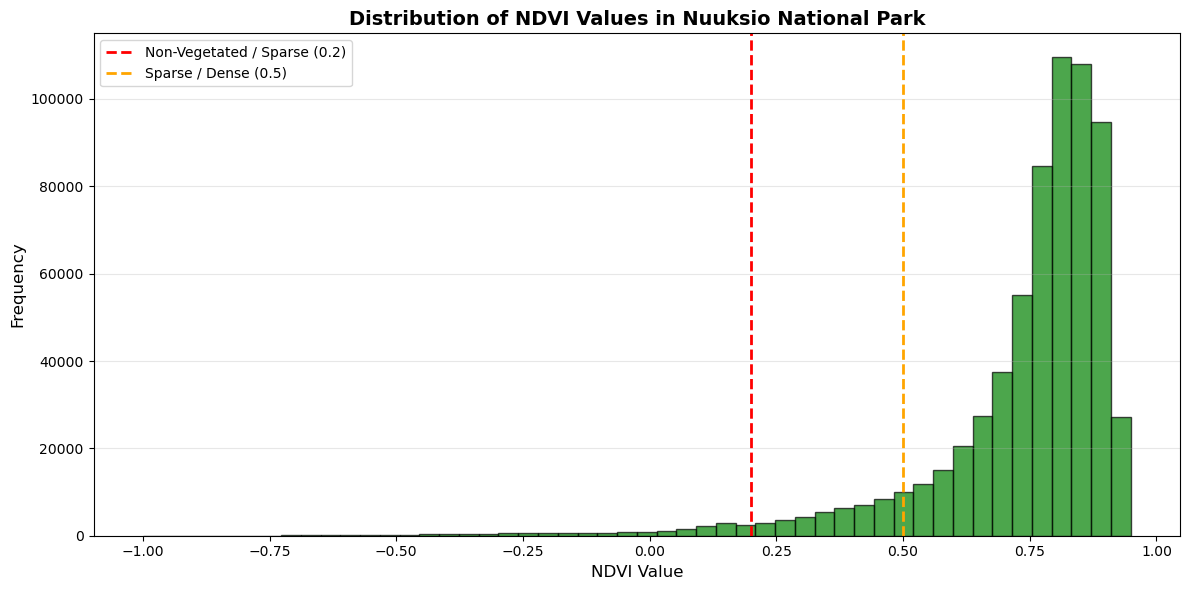

In [8]:
# Create a histogram of NDVI values
fig, ax = plt.subplots(figsize=(12, 6))

# Flatten the NDVI array and remove NaN values
ndvi_values = NDVI.values.flatten()
ndvi_values = ndvi_values[~np.isnan(ndvi_values)]

# Create histogram
ax.hist(ndvi_values, bins=50, color='green', alpha=0.7, edgecolor='black')

# Customize labels and title
ax.set_xlabel('NDVI Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of NDVI Values in Nuuksio National Park', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add vertical lines for classification thresholds
ax.axvline(x=0.2, color='red', linestyle='--', linewidth=2, label='Non-Vegetated / Sparse (0.2)')
ax.axvline(x=0.5, color='orange', linestyle='--', linewidth=2, label='Sparse / Dense (0.5)')
ax.legend()

plt.tight_layout()
plt.show()